In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(10,6))

# Load datasets
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
transactions = pd.read_csv("../data/processed/08_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

<Figure size 1000x600 with 0 Axes>

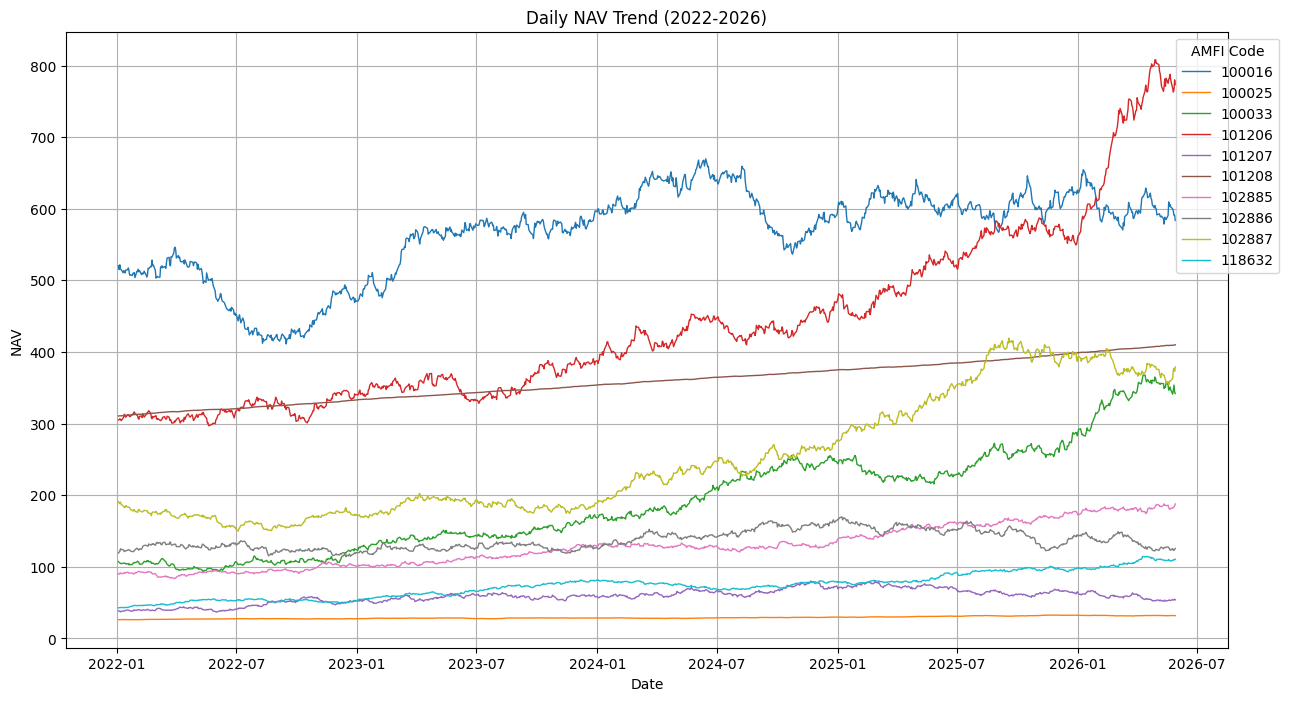

In [28]:
import matplotlib.pyplot as plt

nav["date"] = pd.to_datetime(nav["date"])

sample_funds = nav["amfi_code"].unique()[:10]  # Use first 10 funds for readability

plt.figure(figsize=(15,8))

for fund in sample_funds:
    fund_data = nav[nav["amfi_code"] == fund]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund),
        linewidth=1
    )

plt.title("Daily NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(title="AMFI Code", bbox_to_anchor=(1.05,1))
plt.grid(True)

plt.savefig(
    "../reports/charts/chart1_daily_nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

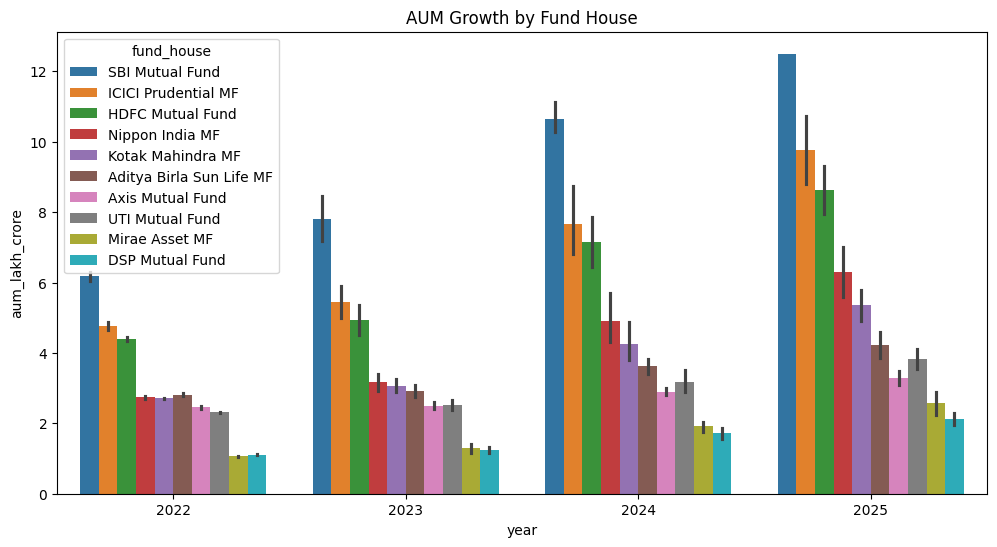

In [4]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.savefig(
    "../reports/charts/chart2_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

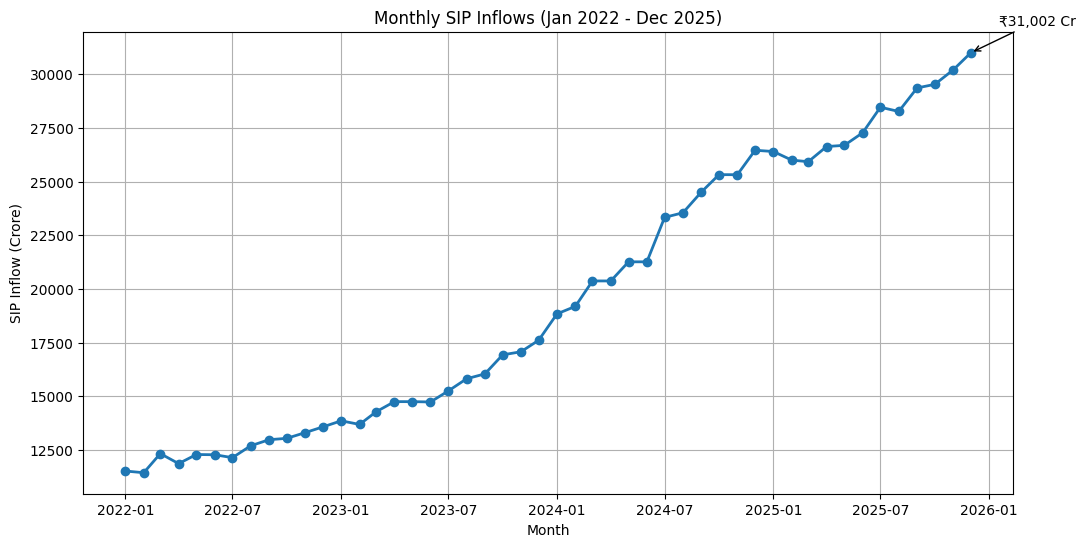

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title("Monthly SIP Inflows (Jan 2022 - Dec 2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

# Mark highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.annotate(
    f"₹{max_row['sip_inflow_crore']:,.0f} Cr",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.savefig(
    "../reports/charts/chart3_sip_inflow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

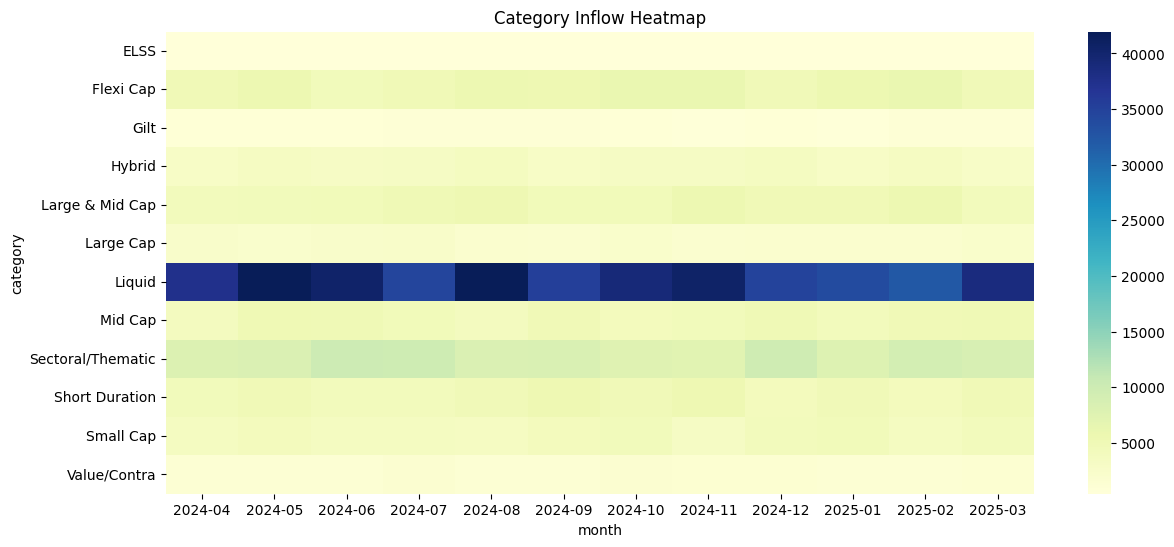

In [10]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.savefig(
    "../reports/charts/chart4_category_inflow.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

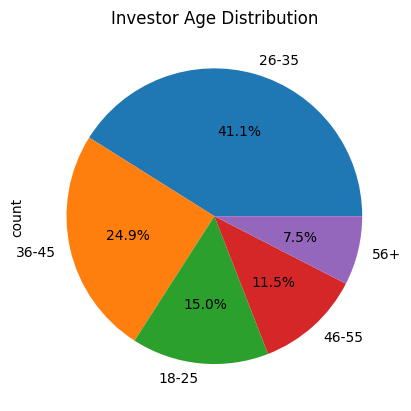

In [11]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")
plt.savefig(
    "../reports/charts/chart5_investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

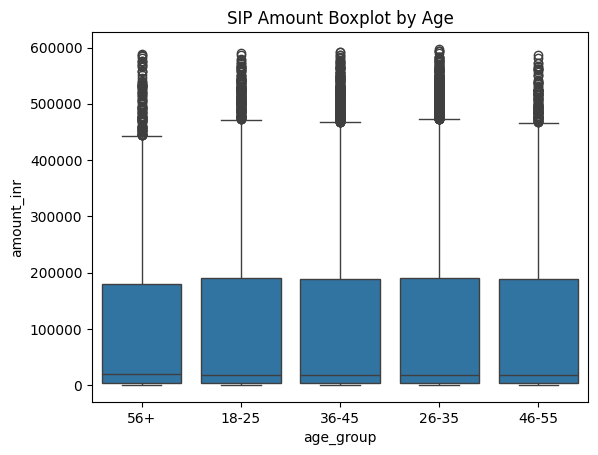

In [12]:
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)
plt.title("SIP Amount Boxplot by Age")
plt.savefig(
    "../reports/charts/chart6_sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

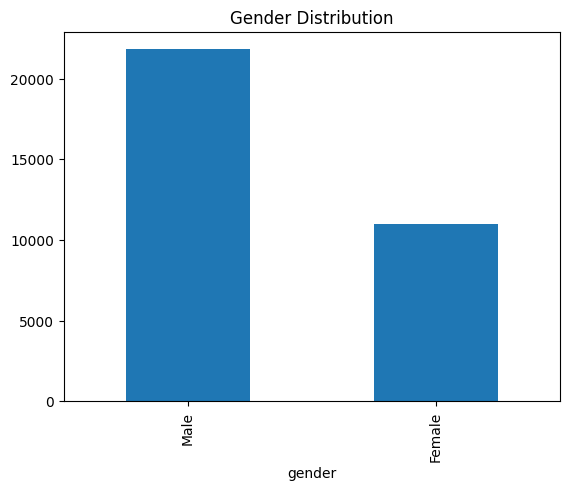

In [13]:
transactions["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.savefig(
    "../reports/charts/chart7_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

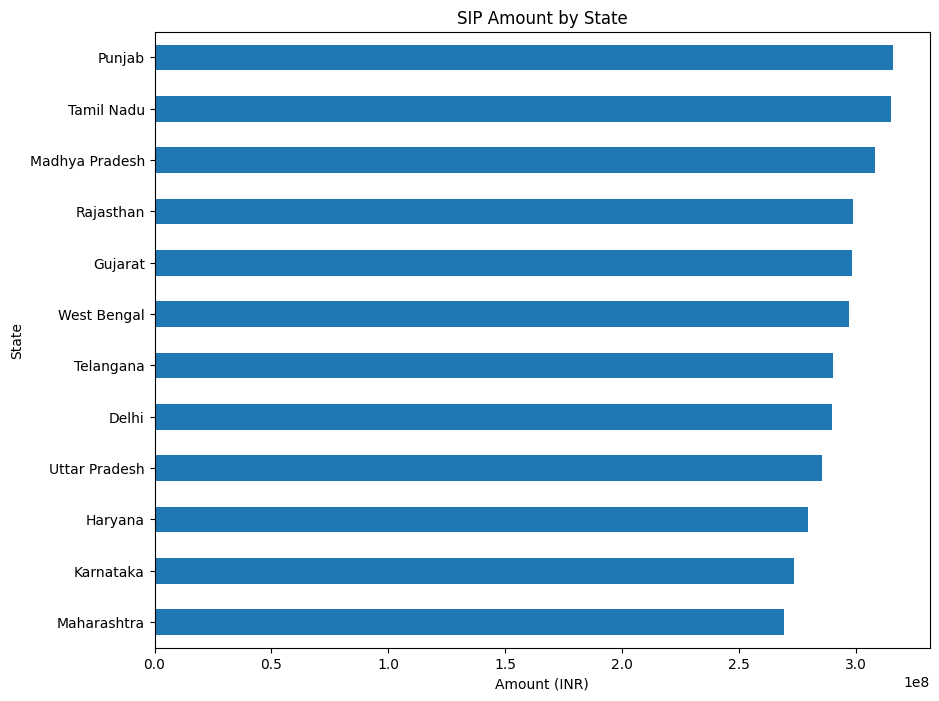

In [14]:
state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

state_data.plot(
    kind="barh",
    figsize=(10,8)
)
plt.title("SIP Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")
plt.savefig(
    "../reports/charts/chart8_sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

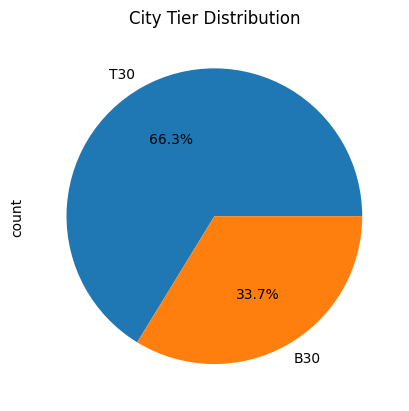

In [15]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("City Tier Distribution")
plt.savefig(
    "../reports/charts/chart9_city_Tier_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

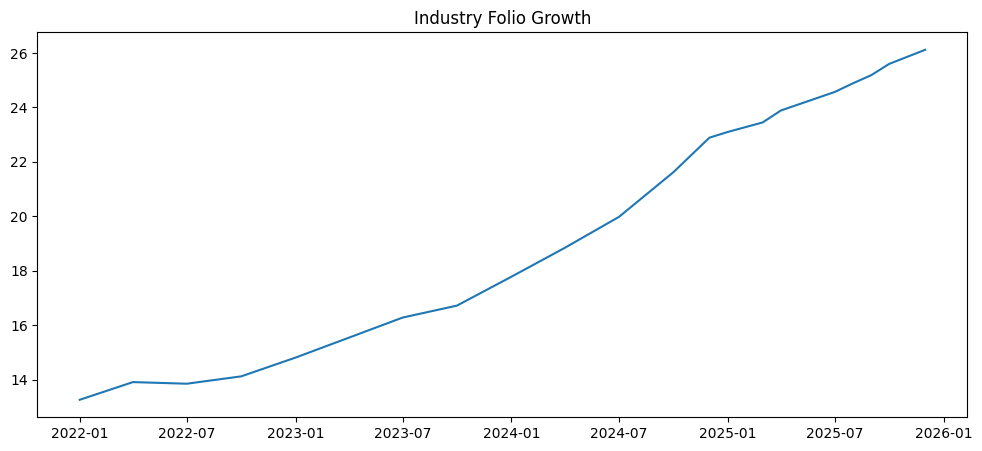

In [16]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(12,5))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.savefig(
    "../reports/charts/chart10_Industry_Folio_Growth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

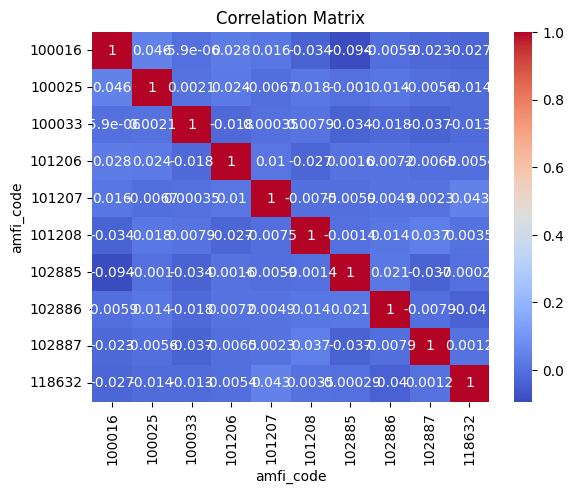

In [17]:
sample_funds = (
    nav["amfi_code"]
    .unique()[:10]
)

returns = (
    nav[
        nav["amfi_code"]
        .isin(sample_funds)
    ]
)

pivot = returns.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = pivot.pct_change()

corr = daily_returns.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.savefig(
    "../reports/charts/chart11_Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

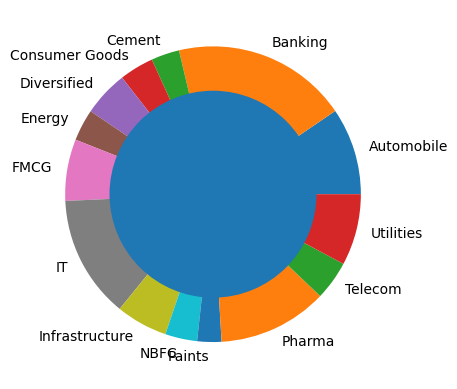

In [18]:
sector = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
)

plt.pie(
    sector,
    labels=sector.index
)

centre = plt.Circle((0,0),0.70)
plt.gca().add_artist(centre)
plt.savefig(
    "../reports/charts/chart12_Sector Allocation Donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

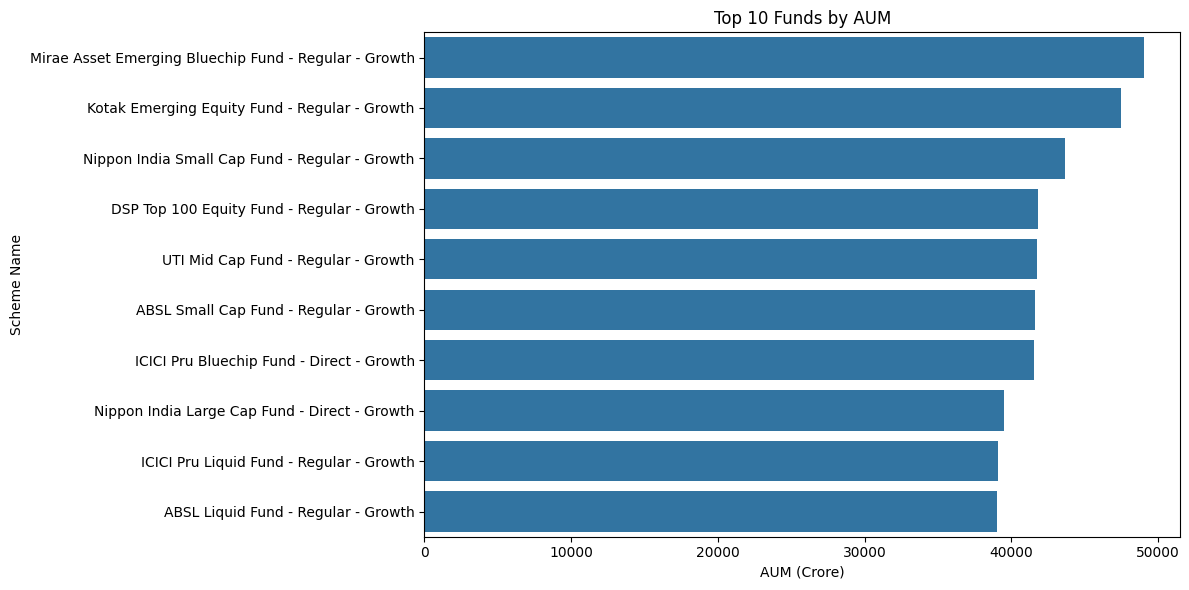

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

top_funds = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.savefig(
    "../reports/charts/chart13_Top 10 Funds by AUM.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

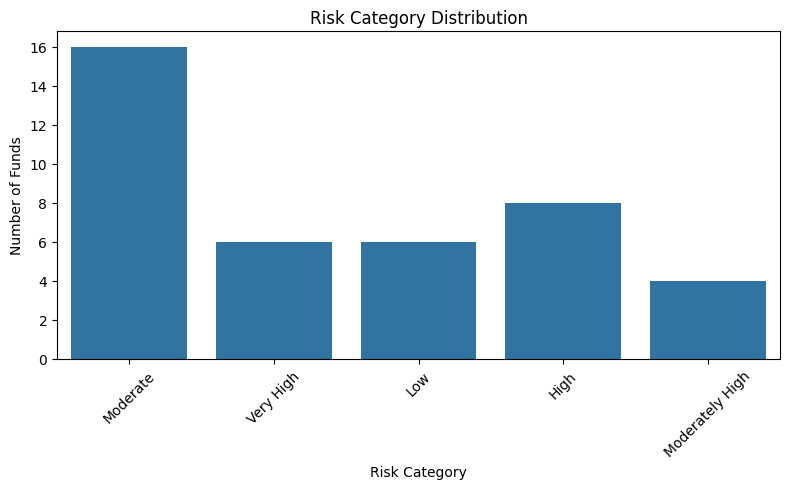

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="risk_category"
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "../reports/charts/chart14_Risk Category Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

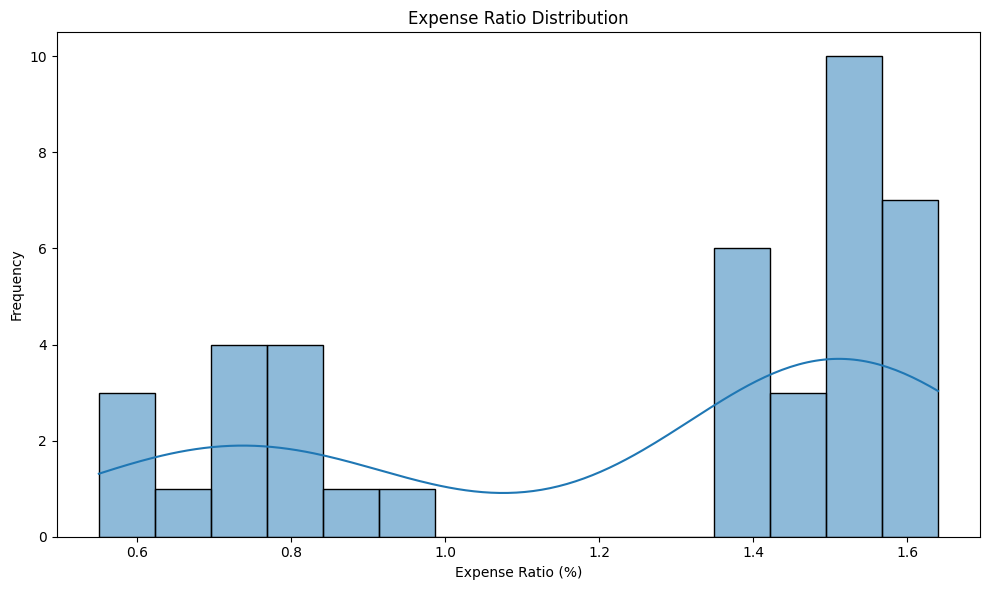

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    fund_master["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(
    "../reports/charts/chart15_Expense Ratio Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Insight 1:
SBI Mutual Fund maintained the highest AUM across the analysis period.

Insight 2:
SIP inflows grew consistently from 2022 to 2025 and reached a record high in Dec 2025.

Insight 3:
Industry folio count increased from 13.26 Cr to 26.12 Cr, indicating rapid investor growth.

Insight 4:
The 26–35 age group contributes the largest share of investments.

Insight 5:
T30 cities account for a higher investment volume than B30 cities.

Insight 6:
Large-cap and flexi-cap categories attracted the highest inflows.

Insight 7:
Most schemes have expense ratios below 2%.

Insight 8:
Banking and IT sectors dominate portfolio allocations.

Insight 9:
Most selected funds exhibit strong positive return correlations.

Insight 10:
Higher-risk funds generally generated stronger long-term returns.
